In [1]:
import numpy as np
import pandas as pd
import os
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import json
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [ ]:
# 4.1.1 token count 

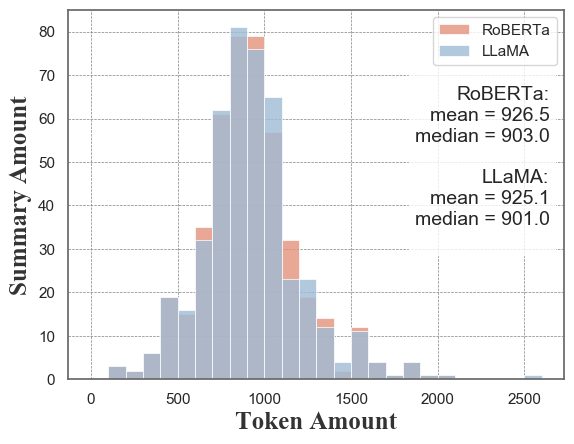

In [142]:
sns.set(style="whitegrid", palette="pastel")
df = pd.read_csv("results/token_counts.csv")

fig, ax = plt.subplots()

bins = list(range(0, 2700, 100))
colors = {'roberta': '#E4937C', 'llama': '#9fbbd5'}

sns.histplot(df['roberta'],
             bins=bins,
             color=colors['roberta'],
             alpha=0.8,
             label='RoBERTa',
             edgecolor='white',
             linewidth=0.5,
             ax=ax)

sns.histplot(df['llama'],
             bins=bins,
             color=colors['llama'],
             alpha=0.8,
             label='LLaMA',
             edgecolor='white',
             linewidth=0.5,
             ax=ax)

stats_text = f'''
RoBERTa:
mean = {df.roberta.mean():.1f}
median = {df.roberta.median():.1f}

LLaMA:
mean = {df.llama.mean():.1f}
median = {df.llama.median():.1f}
'''

plt.gca().spines['top'].set_color('dimgrey')      
plt.gca().spines['bottom'].set_color('dimgrey')   
plt.gca().spines['left'].set_color('dimgrey')     
plt.gca().spines['right'].set_color('dimgrey')
plt.grid(color='gray', linestyle='--', linewidth=0.5)  

ax.text(0.97, 0.85, stats_text,
         transform=ax.transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.8), size=14)

ax.legend()

plt.xlabel("Token Amount", fontdict={'size':18, 'color':'#333333', 'family':'Times New Roman'})
plt.ylabel("Summary Amount", fontdict={'size':18, 'color':'#333333', 'family':'Times New Roman'})
plt.savefig('images/token_analysis.pdf', format='pdf')

In [ ]:
# 4.2.2 token amount z for LLM-gen

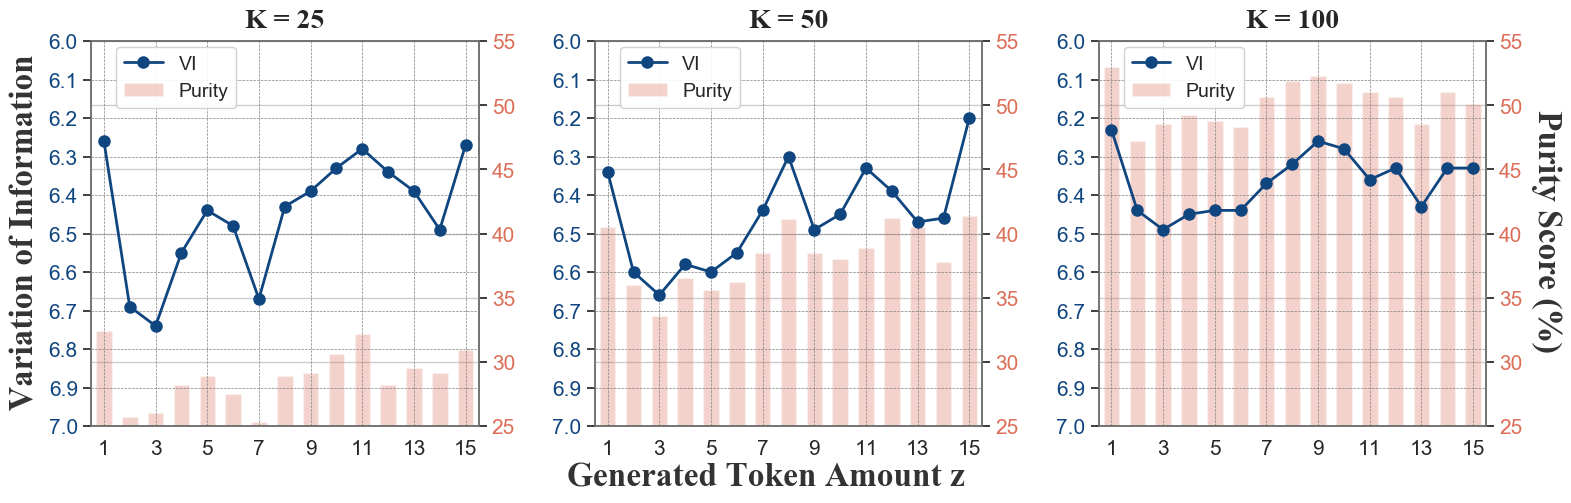

In [164]:
VI_25 = [6.26, 6.69, 6.74, 6.55, 6.44, 6.48, 6.67, 6.43, 6.39, 6.33, 6.28, 6.34, 6.39, 6.49, 6.27]
VI_50 = [6.34, 6.60, 6.66, 6.58, 6.60, 6.55, 6.44, 6.30, 6.49, 6.45, 6.33, 6.39, 6.47, 6.46, 6.20]
VI_100 = [6.23, 6.44, 6.49, 6.45, 6.44, 6.44, 6.37, 6.32, 6.26, 6.28, 6.36, 6.33, 6.43, 6.33, 6.33]

Purity_25 = [32.4, 25.7, 26.0, 28.2, 28.9, 27.5, 25.3, 28.9, 29.1, 30.6, 32.2, 28.2, 29.5, 29.1, 30.9]
Purity_50 = [40.5, 36.0, 33.6, 36.5, 35.6, 36.2, 38.5, 41.1, 38.5, 38.0, 38.9, 41.2, 40.5, 37.8, 41.4]
Purity_100 = [53.0, 47.2, 48.5, 49.2, 48.8, 48.3, 50.6, 51.9, 52.3, 51.7, 51.0, 50.6, 48.5, 51.0, 50.1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3) 

vi_color = '#104680'
purity_color = '#DC6D57'
purity_alpha = 0.3

x = np.arange(15)

for i, (k, vi_data, purity_data) in enumerate(zip([25, 50, 100], 
                                                [VI_25, VI_50, VI_100],
                                                [Purity_25, Purity_50, Purity_100])):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)
    
    bars = ax2.bar(x, purity_data, width=0.6, color=purity_color, 
                  alpha=purity_alpha, label='Purity', zorder=1)
    ax2.set_ylim(25, 55)
    ax2.yaxis.set_major_locator(MultipleLocator(5))
    ax2.tick_params(axis='y', labelsize=15, labelcolor=purity_color)
    
    line = ax1.plot(vi_data, linestyle='-', linewidth=2, marker='o', 
                   markersize=8, color=vi_color, label='VI', zorder=3)
    ax1.set_ylim(7.0, 6.0)
    ax1.yaxis.set_major_locator(MultipleLocator(0.1))
    ax1.tick_params(axis='y', labelsize=15, labelcolor=vi_color)
    
    ax1.set_xlim(-0.5, 14.5)
    ax1.set_xticks([0, 2, 4, 6, 8, 10, 12, 14])
    ax1.set_xticklabels(['1', '3', '5', '7', '9', '11', '13', '15'], fontsize=15)
    
    ax1.set_title(f'K = {k}', fontsize=20, pad=10, family='Times New Roman')
    
    for spine in ax1.spines.values():
        spine.set_color('dimgrey')
    ax1.grid(color='gray', linestyle='--', linewidth=0.5)
    
    lines = [line[0], bars]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=14,
               bbox_to_anchor=(0.04, 1.01), framealpha=0.9)

fig.text(0.5, -0.01, 'Generated Token Amount z', ha='center', 
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})
fig.text(0.08, 0.5, 'Variation of Information', va='center', rotation='vertical',
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})
fig.text(0.925, 0.5, 'Purity Score (%)', va='center', rotation=-90,
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})

plt.savefig('images/LLM-gen-z.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
# 4.2.2 layer L for LLM-gen

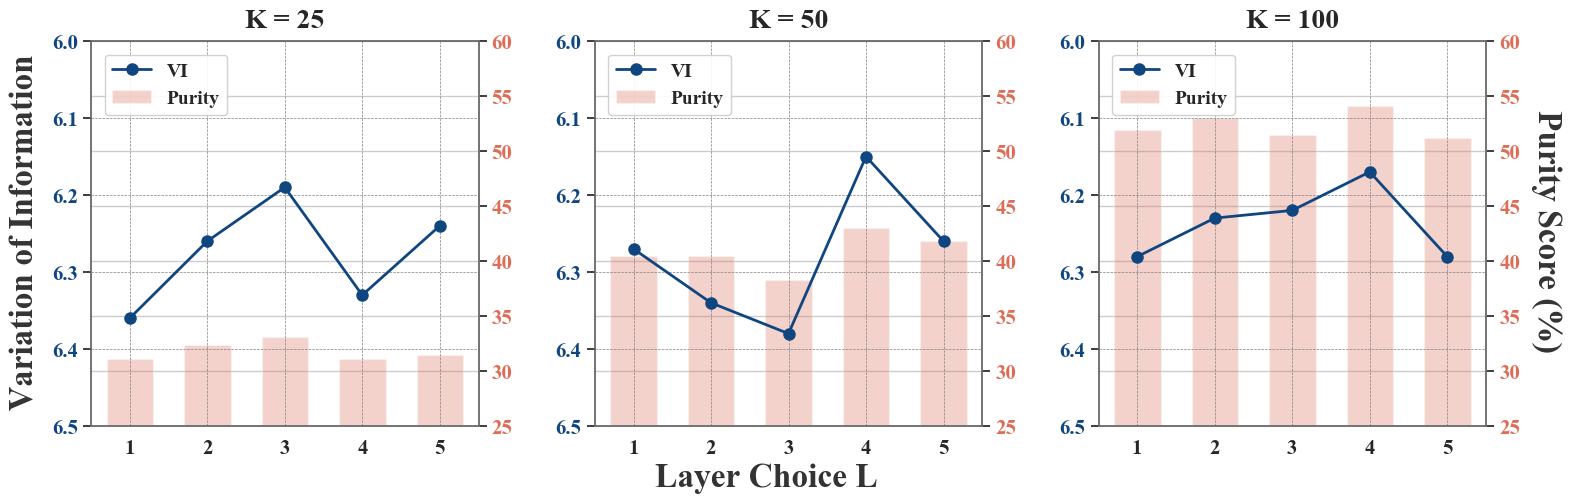

In [212]:
VI_25 = [6.36, 6.26, 6.19, 6.33, 6.24]
VI_50 = [6.27, 6.34, 6.38, 6.15, 6.26]
VI_100 = [6.28, 6.23, 6.22, 6.17, 6.28]

Purity_25 = [31.1, 32.4, 33.1, 31.1, 31.5]
Purity_50 = [40.5, 40.5, 38.3, 43.0, 41.8]
Purity_100 = [51.9, 53.0, 51.5, 54.1, 51.2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3) 

vi_color = '#104680'
purity_color = '#DC6D57'
purity_alpha = 0.3

x = np.arange(5)

for i, (k, vi_data, purity_data) in enumerate(zip([25, 50, 100], 
                                                [VI_25, VI_50, VI_100],
                                                [Purity_25, Purity_50, Purity_100])):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)
    
    bars = ax2.bar(x, purity_data, width=0.6, color=purity_color, 
                  alpha=purity_alpha, label='Purity', zorder=1)
    ax2.set_ylim(25, 60)
    ax2.yaxis.set_major_locator(MultipleLocator(5))
    ax2.tick_params(axis='y', labelsize=15, labelcolor=purity_color)
    
    line = ax1.plot(vi_data, linestyle='-', linewidth=2, marker='o', 
                   markersize=8, color=vi_color, label='VI', zorder=3)
    ax1.set_ylim(6.5, 6.0)
    ax1.yaxis.set_major_locator(MultipleLocator(0.1))
    ax1.tick_params(axis='y', labelsize=15, labelcolor=vi_color)
    
    ax1.set_xlim(-0.5, 4.5)
    ax1.set_xticks([0, 1, 2, 3, 4])
    ax1.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=15)
    
    ax1.set_title(f'K = {k}', fontsize=20, pad=10, family='Times New Roman')
    
    for spine in ax1.spines.values():
        spine.set_color('dimgrey')
    ax1.grid(color='gray', linestyle='--', linewidth=0.5)
    
    lines = [line[0], bars]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=14, 
               bbox_to_anchor=(0.01, 0.99), framealpha=0.9)

fig.text(0.5, -0.01, 'Layer Choice L', ha='center', 
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})
fig.text(0.08, 0.5, 'Variation of Information', va='center', rotation='vertical',
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})
fig.text(0.92, 0.5, 'Purity Score (%)', va='center', rotation=-90,
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})

plt.savefig('images/LLM-gen-L.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
# 4.2.3 LLM-con methods and layer choices

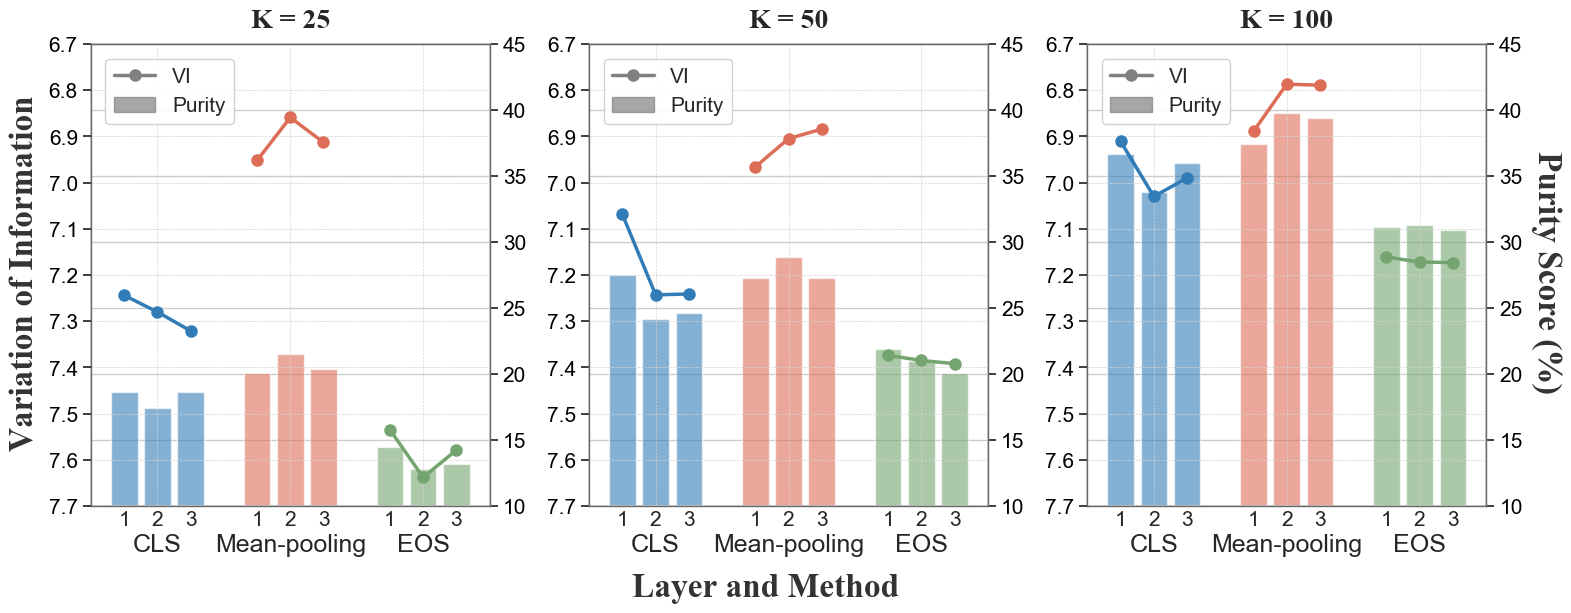

In [183]:
data = {
    "CLS": {
        "VI": {
            25: [7.244, 7.280, 7.321],
            50: [7.069, 7.243, 7.241],
            100: [6.911, 7.030, 6.990]
        },
        "Purity": {
            25: [18.6, 17.4, 18.6],
            50: [27.5, 24.2, 24.6],
            100: [36.7, 33.8, 36.0]
        }
    },
    "Mean-pooling": {
        "VI": {
            25: [6.952, 6.859, 6.913],
            50: [6.966, 6.905, 6.884],
            100: [6.889, 6.787, 6.789]
        },
        "Purity": {
            25: [20.1, 21.5, 20.4],
            50: [27.3, 28.9, 27.3],
            100: [37.4, 39.8, 39.4]
        }
    },
    "EOS": {
        "VI": {
            25: [7.535, 7.638, 7.579],
            50: [7.374, 7.385, 7.392],
            100: [7.161, 7.172, 7.173]
        },
        "Purity": {
            25: [14.5, 12.8, 13.2],
            50: [21.9, 21.0, 20.1],
            100: [31.1, 31.3, 30.9]
        }
    }
}

method_colors = {
    "CLS": "#317CB7", 
    "Mean-pooling": "#DC6D57",  
    "EOS": "#74A46F"   
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.25)  

methods = ["CLS", "Mean-pooling", "EOS"]
layer_labels = ["1", "2", "3"]

metric_legend = [
    Line2D([0], [0], color='gray', marker='o', linestyle='-', markersize=8, linewidth=2.5, label='VI'),
    mpatches.Patch(color='gray', alpha=0.7, label='Purity')
]

group_positions = [0, 4, 8] 
layer_offsets = [0, 1, 2] 

k_values = [25, 50, 100]

for idx, k in enumerate(k_values):
    ax1 = axes[idx]
    ax2 = ax1.twinx() 
    
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    line_handles = []
    
    for group_idx, method in enumerate(methods):
        color = method_colors[method]
        
        group_x = group_positions[group_idx]
        vi_values = data[method]["VI"][k]
        purity_values = data[method]["Purity"][k]
        
        for layer_idx, offset in enumerate(layer_offsets):
            x_pos = group_x + offset
            ax2.bar(x_pos, purity_values[layer_idx], width=0.8, 
                    color=color, alpha=0.6, zorder=1)
        
        x_positions = [group_x + offset for offset in layer_offsets]
        line, = ax1.plot(x_positions, vi_values, 
                         marker='o', markersize=8, linewidth=2.5,
                         color=color, zorder=3, 
                         label=f"{method.capitalize()} VI")
    
    ax1.set_ylim(7.7, 6.7)
    ax1.yaxis.set_major_locator(MultipleLocator(0.1))
    ax1.tick_params(axis='y', labelsize=15, labelcolor='black')
    
    ax2.set_ylim(10, 45)
    ax2.yaxis.set_major_locator(MultipleLocator(5))
    ax2.tick_params(axis='y', labelsize=15, labelcolor='black')
    
    ax1.set_xlim(-1, 11)
    
    group_label_positions = [group_positions[0] + 1, 
                            group_positions[1] + 1, 
                            group_positions[2] + 1]
    
    ax1.set_xticks(group_label_positions)
    ax1.set_xticklabels([m for m in methods], fontsize=18)
    
    for label in ax1.get_xticklabels():
        label.set_y(label.get_position()[1] - 0.03) 
    
    for group_x in group_positions:
        for layer_idx, offset in enumerate(layer_offsets):
            x_pos = group_x + offset
            ax1.text(x_pos, 7.71, layer_labels[layer_idx], 
                     ha='center', va='top', fontsize=15)
    
    ax1.set_title(f'K = {k}', fontsize=20, pad=12, family='Times New Roman')
    
    ax1.grid(color='lightgray', linestyle='--', linewidth=0.5, zorder=0)
    for spine in ax1.spines.values():
        spine.set_color('dimgrey')
        spine.set_linewidth(1)
    ax1.legend(handles=metric_legend, loc='upper left', fontsize=15, 
           bbox_to_anchor=(0.01, 0.99), framealpha=0.9)

method_legend = [
    mpatches.Patch(color=method_colors["CLS"], label='CLS'),
    mpatches.Patch(color=method_colors["Mean-pooling"], label='Mean-pooling'),
    mpatches.Patch(color=method_colors["EOS"], label='EOS')
]

fig.text(0.5, -0.04, 'Layer and Method', ha='center', 
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})
fig.text(0.08, 0.5, 'Variation of Information', va='center', rotation='vertical',
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})
fig.text(0.925, 0.5, 'Purity Score (%)', va='center', rotation=-90,
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})


plt.savefig('images/LLM-con.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
# 4.2.4 PLM CLS

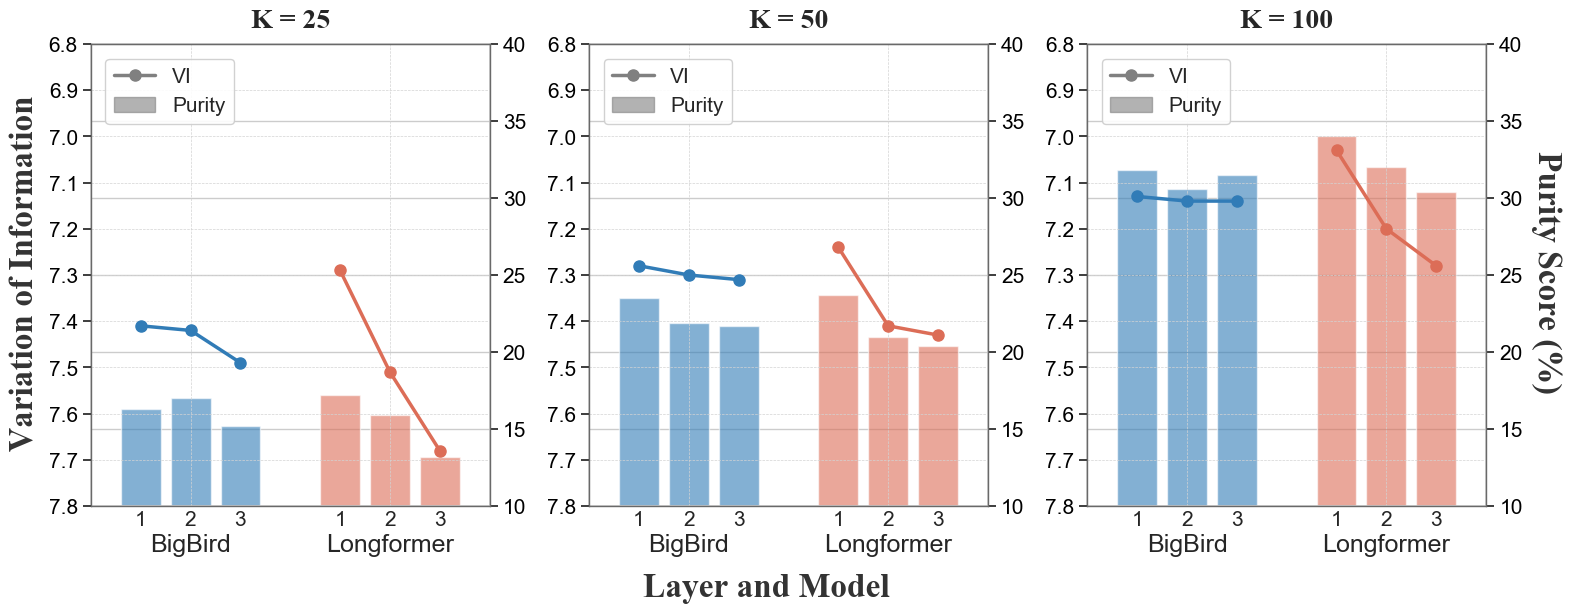

In [195]:
data = {
    "BigBird": {
        "VI": {
            25: [7.41, 7.42, 7.49],
            50: [7.28, 7.30, 7.31],
            100: [7.13, 7.14, 7.14]
        },
        "Purity": {
            25: [16.3, 17.0, 15.2],
            50: [23.5, 21.9, 21.7],
            100: [31.8, 30.6, 31.5]
        }
    },
    "Longformer": {
        "VI": {
            25: [7.29, 7.51, 7.68],
            50: [7.24, 7.41, 7.43],
            100: [7.03, 7.20, 7.28]
        },
        "Purity": {
            25: [17.2, 15.9, 13.2],
            50: [23.7, 21.0, 20.4],
            100: [34.0, 32.0, 30.4]
        }
    }
}


model_colors = {
    "BigBird": "#317CB7", 
    "Longformer": "#DC6D57" 
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.25) 

models = ["BigBird", "Longformer"]
layer_labels = ["1", "2", "3"]

group_positions = [0, 4] 
layer_offsets = [0, 1, 2] 

k_values = [25, 50, 100]

metric_legend = [
    Line2D([0], [0], color='gray', marker='o', linestyle='-', markersize=8, linewidth=2.5, label='VI'),
    mpatches.Patch(color='gray', alpha=0.6, label='Purity')
]

for idx, k in enumerate(k_values):
    ax1 = axes[idx]
    ax2 = ax1.twinx() 
    
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    for group_idx, model in enumerate(models):
        color = model_colors[model]
        
        group_x = group_positions[group_idx]
        
        vi_values = data[model]["VI"][k]
        purity_values = data[model]["Purity"][k]
        
        for layer_idx, offset in enumerate(layer_offsets):
            x_pos = group_x + offset
            ax2.bar(x_pos, purity_values[layer_idx], width=0.8, 
                    color=color, alpha=0.6, zorder=1)
        
        x_positions = [group_x + offset for offset in layer_offsets]
        line, = ax1.plot(x_positions, vi_values, 
                         marker='o', markersize=8, linewidth=2.5,
                         color=color, zorder=3, 
                         label=f"{model} VI")
    
    ax1.set_ylim(7.8, 6.8)
    ax1.yaxis.set_major_locator(MultipleLocator(0.1))
    ax1.tick_params(axis='y', labelsize=15, labelcolor='black')
    
    ax2.set_ylim(10, 40)
    ax2.yaxis.set_major_locator(MultipleLocator(5))
    ax2.tick_params(axis='y', labelsize=15, labelcolor='black')
    
    ax1.set_xlim(-1, 7)

    group_label_positions = [group_positions[0] + 1, 
                            group_positions[1] + 1]
    
    ax1.set_xticks(group_label_positions)
    ax1.set_xticklabels([m for m in models], fontsize=18)
  
    for label in ax1.get_xticklabels():
        label.set_y(label.get_position()[1] - 0.03) 

    for group_x in group_positions:
        for layer_idx, offset in enumerate(layer_offsets):
            x_pos = group_x + offset
            ax1.text(x_pos, 7.81, layer_labels[layer_idx], 
                     ha='center', va='top', fontsize=15)
    
    ax1.set_title(f'K = {k}', fontsize=20, pad=12, family='Times New Roman')

    ax1.grid(color='lightgray', linestyle='--', linewidth=0.5, zorder=0)
    for spine in ax1.spines.values():
        spine.set_color('dimgrey')
        spine.set_linewidth(1)
    
    ax1.legend(handles=metric_legend, loc='upper left', fontsize=15, 
           bbox_to_anchor=(0.01, 0.99), framealpha=0.9)

model_legend = [
    mpatches.Patch(color=model_colors["BigBird"], label='BigBird'),
    mpatches.Patch(color=model_colors["Longformer"], label='Longformer')
]

fig.text(0.5, -0.04, 'Layer and Model', ha='center', 
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})
fig.text(0.08, 0.5, 'Variation of Information', va='center', rotation='vertical',
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})
fig.text(0.925, 0.5, 'Purity Score (%)', va='center', rotation=-90,
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})

plt.savefig('images/PLM-CLS.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
# 4.2.5 PLM MASK

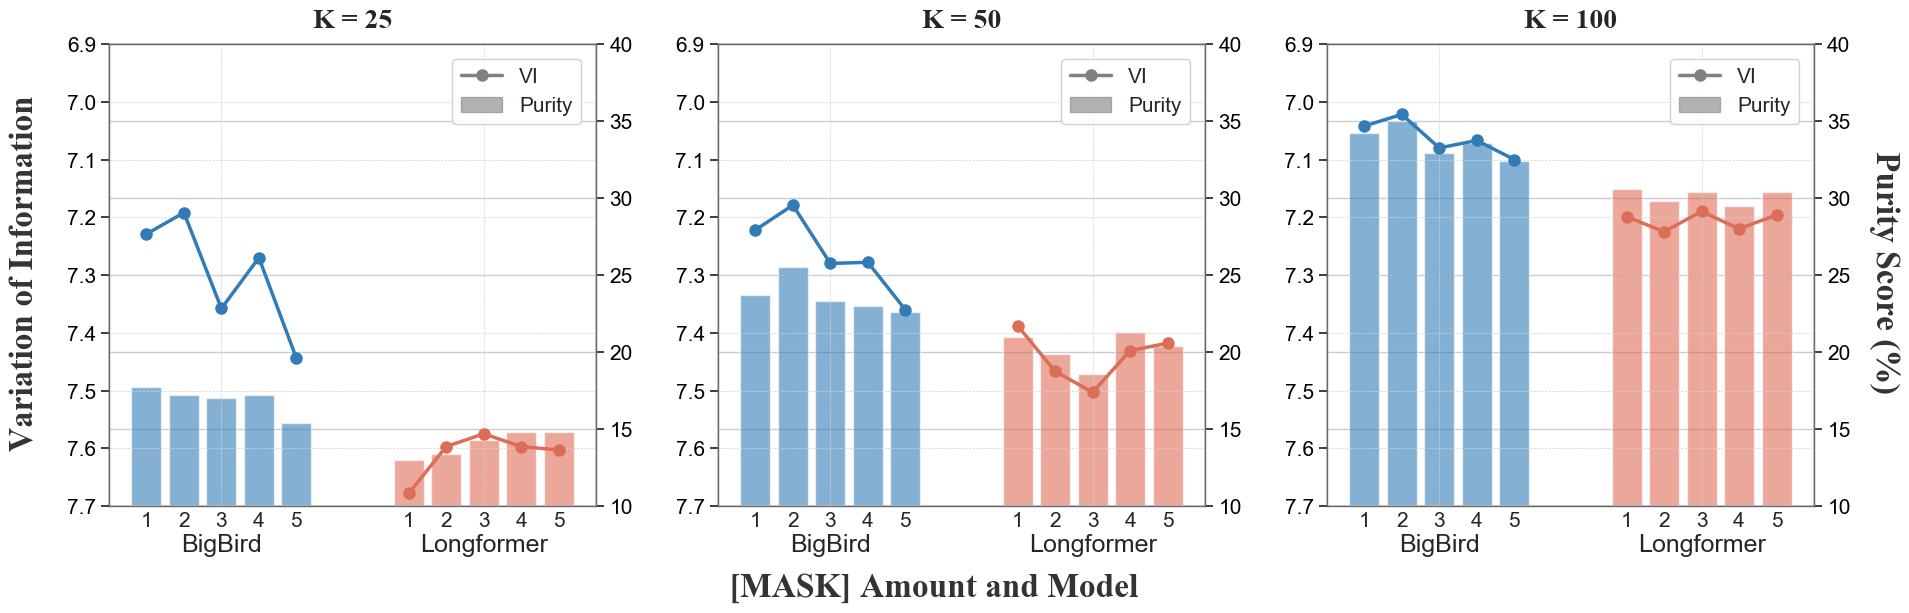

In [197]:
data = {
    "BigBird": {
        "VI": {
            25: [7.229, 7.192, 7.358, 7.270, 7.444],
            50: [7.222, 7.179, 7.280, 7.278, 7.360],
            100: [7.042, 7.022, 7.080, 7.067, 7.100]
        },
        "Purity": {
            25: [17.7, 17.2, 17.0, 17.2, 15.4],
            50: [23.7, 25.5, 23.3, 23.0, 22.6],
            100: [34.2, 35.0, 32.9, 33.6, 32.4]
        }
    },
    "Longformer": {
        "VI": {
            25: [7.678, 7.597, 7.575, 7.597, 7.603],
            50: [7.388, 7.467, 7.503, 7.431, 7.418],
            100: [7.199, 7.225, 7.190, 7.220, 7.196]
        },
        "Purity": {
            25: [13.0, 13.4, 14.3, 14.8, 14.8],
            50: [21.0, 19.9, 18.6, 21.3, 20.4],
            100: [30.6, 29.8, 30.4, 29.5, 30.4]
        }
    }
}

model_colors = {
    "BigBird": "#317CB7", 
    "Longformer": "#DC6D57"  
}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
plt.subplots_adjust(wspace=0.25) 

models = ["BigBird", "Longformer"]
mask_labels = ["1", "2", "3", "4", "5"]

group_positions = [0, 7]
layer_offsets = [0, 1, 2, 3, 4] 

k_values = [25, 50, 100]

metric_legend = [
    Line2D([0], [0], color='gray', marker='o', linestyle='-', markersize=8, linewidth=2.5, label='VI'),
    mpatches.Patch(color='gray', alpha=0.6, label='Purity')
]

for idx, k in enumerate(k_values):
    ax1 = axes[idx]
    ax2 = ax1.twinx() 
    
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    for group_idx, model in enumerate(models):
        color = model_colors[model]
        
        group_x = group_positions[group_idx]
        
        vi_values = data[model]["VI"][k]
        purity_values = data[model]["Purity"][k]
        
        for mask_idx, offset in enumerate(layer_offsets):
            x_pos = group_x + offset
            ax2.bar(x_pos, purity_values[mask_idx], width=0.8, 
                    color=color, alpha=0.6, zorder=1)
        
        x_positions = [group_x + offset for offset in layer_offsets]
        line, = ax1.plot(x_positions, vi_values, 
                         marker='o', markersize=8, linewidth=2.5,
                         color=color, zorder=3, 
                         label=f"{model} VI")
    
    ax1.set_ylim(7.7, 6.9)
    ax1.yaxis.set_major_locator(MultipleLocator(0.1))
    ax1.tick_params(axis='y', labelsize=15, labelcolor='black')

    ax2.set_ylim(10, 40)
    ax2.yaxis.set_major_locator(MultipleLocator(5))
    ax2.tick_params(axis='y', labelsize=15, labelcolor='black')

    ax1.set_xlim(-1, 12)
    
    # 模型组标签位置（每组中间）
    group_label_positions = [group_positions[0] + 2, 
                            group_positions[1] + 2]  # 中间位置调整
    
    ax1.set_xticks(group_label_positions)
    ax1.set_xticklabels([m for m in models], fontsize=18)
    
    # 调整模型标签位置（向下移动）
    for label in ax1.get_xticklabels():
        label.set_y(label.get_position()[1] - 0.03) 
    
    # 添加mask标签
    for group_x in group_positions:
        for mask_idx, offset in enumerate(layer_offsets):
            x_pos = group_x + offset
            ax1.text(x_pos, 7.71, mask_labels[mask_idx], 
                     ha='center', va='top', fontsize=15)
    
    # 添加标题
    ax1.set_title(f'K = {k}', fontsize=20, pad=12, family='Times New Roman')
    
    # 设置网格和边框
    ax1.grid(color='lightgray', linestyle='--', linewidth=0.5, zorder=0)
    for spine in ax1.spines.values():
        spine.set_color('dimgrey')
        spine.set_linewidth(1)
    
    # 添加指标图例
    ax1.legend(handles=metric_legend, loc='upper right', fontsize=15, 
           bbox_to_anchor=(0.99, 0.99), framealpha=0.9)

# 创建模型图例
model_legend = [
    mpatches.Patch(color=model_colors["BigBird"], label='BigBird'),
    mpatches.Patch(color=model_colors["Longformer"], label='Longformer')
]

# 添加全局标签
fig.text(0.5, -0.04, '[MASK] Number and Model', ha='center', 
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})
fig.text(0.08, 0.5, 'Variation of Information', va='center', rotation='vertical',
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})
fig.text(0.925, 0.5, 'Purity Score (%)', va='center', rotation=-90,
         fontdict={'size': 24, 'color': '#333333', 'family': 'Times New Roman'})

# 添加模型图例
# fig.legend(handles=model_legend, loc='upper center', 
#            bbox_to_anchor=(0.5, 1.1), ncol=2, fontsize=15, frameon=True)

# 保存图片
plt.savefig('images/PLM-mask.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
# 4.3.2 similarity classification

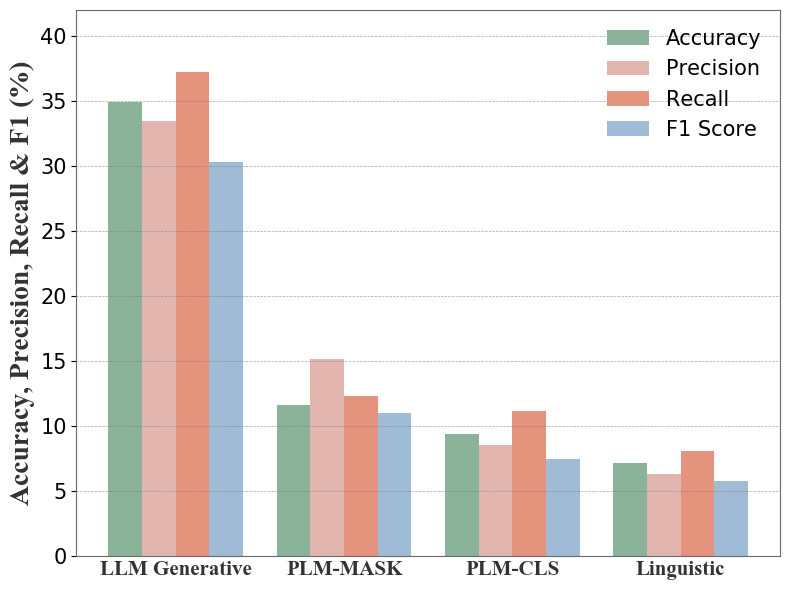

In [4]:
methods = ['LLM Generative', 'PLM-MASK', 'PLM-CLS', 'Linguistic']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

data = np.array([
    [34.90, 33.46, 37.26, 30.33],   # LLM Generative
    [11.63, 15.18, 12.32, 10.97],   # PLM (BigBird) MASK
    [9.40, 8.57, 11.18, 7.48],      # PLM (Longformer) CLS
    [7.16, 6.33, 8.06, 5.77]        # Linguistic
])

colors = ['#8BB39A', '#E2B6AE', '#E4937C', '#9fbbd5']

fig, ax = plt.subplots(figsize=(8, 6))

bar_width = 0.2
x_pos = np.arange(len(methods))

for i in range(len(metrics)):
    ax.bar(
        x_pos + i * bar_width, 
        data[:, i], 
        width=bar_width, 
        label=metrics[i], 
        color=colors[i],
    )

ax.set_xticks(x_pos + bar_width * 1.5)
ax.set_xticklabels(methods, fontsize=15, color='#333333', family='Times New Roman')
ax.tick_params(axis='x', which='major', length=0) 

ax.set_ylabel('Accuracy, Precision, Recall & F1 (%)', fontsize=20, color='#333333', family='Times New Roman')
ax.set_ylim(0, 42)
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(axis='y', labelsize=15)

ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

ax.legend(
    loc='upper right', 
    frameon=False, 
    edgecolor='lightgray',
    fontsize=15
)

for spine in ax.spines.values():
    spine.set_color('dimgrey')

plt.tight_layout()
plt.savefig('images/sim-classification.pdf', format='pdf')
plt.show()

In [ ]:
# 4.3.3 few-shot impact

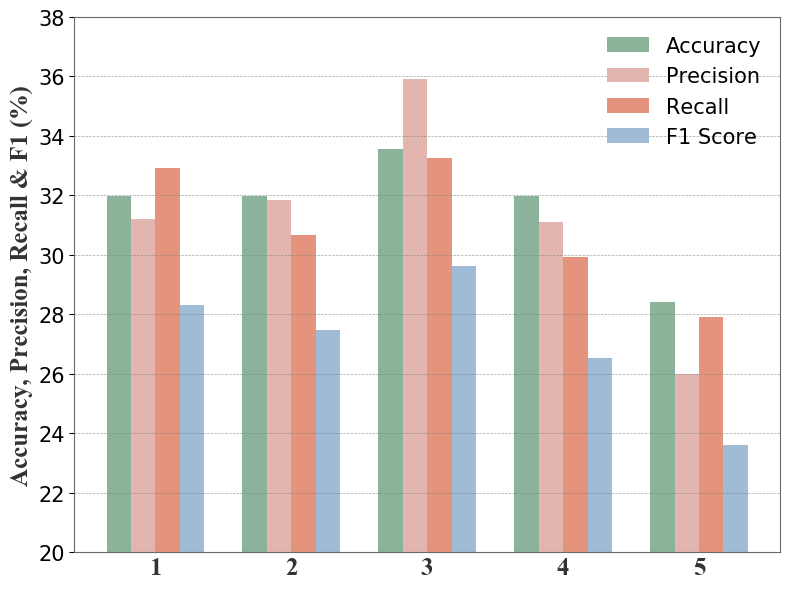

In [6]:
amounts = ['1', '2', '3', '4', '5']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

data = np.array([
    [31.99, 31.21, 32.91, 28.31], 
    [31.99, 31.84, 30.67, 27.46], 
    [33.56, 35.92, 33.27, 29.63],
    [31.99, 31.11, 29.93, 26.54], 
    [28.41, 26.00, 27.92, 23.60]   
])

colors = ['#8BB39A', '#E2B6AE', '#E4937C', '#9fbbd5']

fig, ax = plt.subplots(figsize=(8, 6))

bar_width = 0.18
x_pos = np.arange(len(amounts))

for i in range(len(metrics)):
    ax.bar(
        x_pos + i * bar_width, 
        data[:, i], 
        width=bar_width, 
        label=metrics[i], 
        color=colors[i],
        linewidth=0.8
    )

ax.set_xticks(x_pos + bar_width * 1.5)
ax.set_xticklabels([f"{amount}" for amount in amounts], 
                  fontsize=18, color='#333333', family='Times New Roman')
ax.tick_params(axis='x', which='major', length=0) 

ax.set_ylabel('Accuracy, Precision, Recall & F1 (%)', fontsize=18, color='#333333', family='Times New Roman')
ax.set_ylim(20, 38)
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.tick_params(axis='y', labelsize=15)

ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

ax.legend(
    loc='upper right', 
    frameon=False, 
    fontsize=15,
    ncol=1  
)

for spine in ax.spines.values():
    spine.set_color('dimgrey')

plt.tight_layout()
plt.savefig('images/few-shot-impact.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
# 5.2 clu-cla

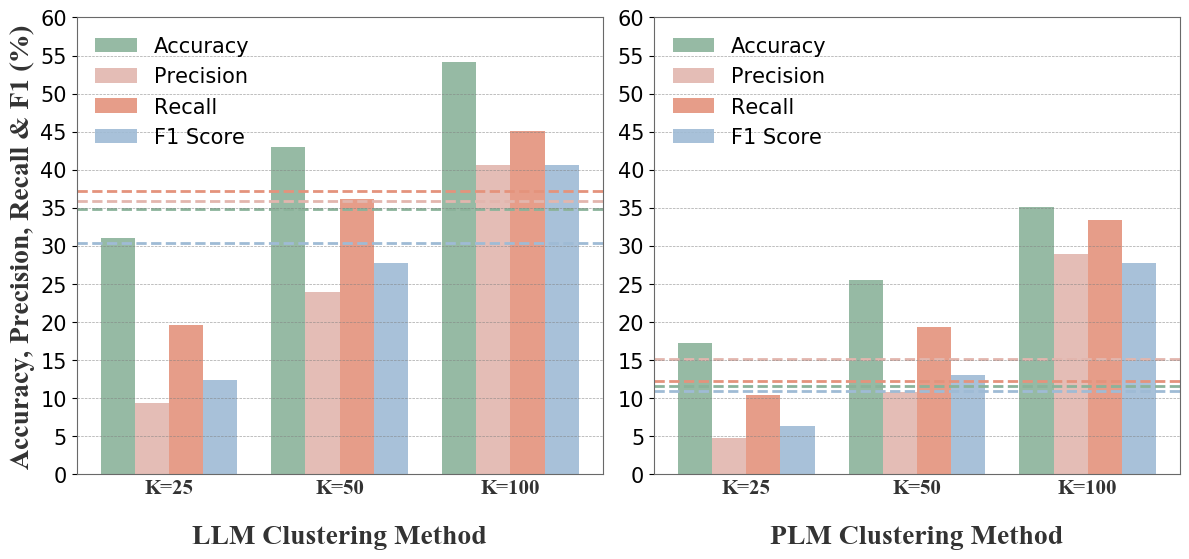

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

methods = ['K=25', 'K=50', 'K=100']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

data_left = np.array([
    [31.1, 9.4, 19.6, 12.4],
    [43.0, 24.0, 36.1, 27.8], 
    [54.1, 40.6, 45.1, 40.6], 
])

colors = ['#8BB39A', '#E2B6AE', '#E4937C', '#9fbbd5']

reference_values = [34.9, 35.92, 37.26, 30.33]
reference_labels = ['Ref Accuracy', 'Ref Precision', 'Ref Recall', 'Ref F1']

for i, (value, color) in enumerate(zip(reference_values, colors)):
    ax1.axhline(y=value, color=color, linestyle='--', linewidth=2, alpha=1, 
               zorder=1, label=reference_labels[i])

bar_width = 0.2
x_pos = np.arange(len(methods))

for i in range(len(metrics)):
    ax1.bar(
        x_pos + i * bar_width, 
        data_left[:, i], 
        width=bar_width, 
        label=metrics[i], 
        color=colors[i],
        alpha=0.9
    )

ax1.set_xticks(x_pos + bar_width * 1.5)
ax1.set_xticklabels(methods, fontsize=15, color='#333333', family='Times New Roman')
ax1.tick_params(axis='x', which='major', length=0) 

ax1.set_ylabel('Accuracy, Precision, Recall & F1 (%)', fontsize=20, color='#333333', family='Times New Roman')
ax1.set_ylim(0, 60)
ax1.yaxis.set_major_locator(MultipleLocator(5))
ax1.tick_params(axis='y', labelsize=15)

ax1.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

handles1, labels1 = ax1.get_legend_handles_labels()

ordered_handles1 = handles1[4:]
ordered_labels1 = labels1[4:]

ax1.legend(
    ordered_handles1, 
    ordered_labels1,
    loc='upper left', 
    frameon=False, 
    fontsize=15,
    ncol=1
)

ax1.text(0.5, -0.15, 'LLM Clustering Method', 
         transform=ax1.transAxes, ha='center', fontsize=20, color='#333333', family='Times New Roman')

for spine in ax1.spines.values():
    spine.set_color('dimgrey')

data_right = np.array([
    [17.2, 4.8, 10.4, 6.3],   
    [25.5, 10.8, 19.3, 13.1],
    [35.1, 28.9, 33.4, 27.8]   
])

reference_values = [11.63, 15.18, 12.32, 10.97]
reference_labels = ['Ref Accuracy', 'Ref Precision', 'Ref Recall', 'Ref F1']

for i, (value, color) in enumerate(zip(reference_values, colors)):
    ax2.axhline(y=value, color=color, linestyle='--', linewidth=2, alpha=1, 
               zorder=1, label=reference_labels[i])

for i in range(len(metrics)):
    ax2.bar(
        x_pos + i * bar_width, 
        data_right[:, i], 
        width=bar_width, 
        label=metrics[i], 
        color=colors[i],
        alpha=0.9
    )

ax2.set_xticks(x_pos + bar_width * 1.5)
ax2.set_xticklabels(methods, fontsize=15, color='#333333', family='Times New Roman')
ax2.tick_params(axis='x', which='major', length=0) 

ax2.set_ylim(0, 60)
ax2.yaxis.set_major_locator(MultipleLocator(5))
ax2.tick_params(axis='y', labelsize=15)

ax2.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

ax2.legend(
    handles=handles1[4:], 
    labels=metrics,
    loc='upper left', 
    frameon=False, 
    fontsize=15,
    ncol=1
)

ax2.text(0.5, -0.15, 'PLM Clustering Method', 
         transform=ax2.transAxes, ha='center', fontsize=20, color='#333333', family='Times New Roman')

for spine in ax2.spines.values():
    spine.set_color('dimgrey')

plt.tight_layout()
plt.subplots_adjust(bottom=0.2) 

plt.savefig('images/clustering-classification.pdf', format='pdf')
plt.show()

In [ ]:
# 5.5 purity

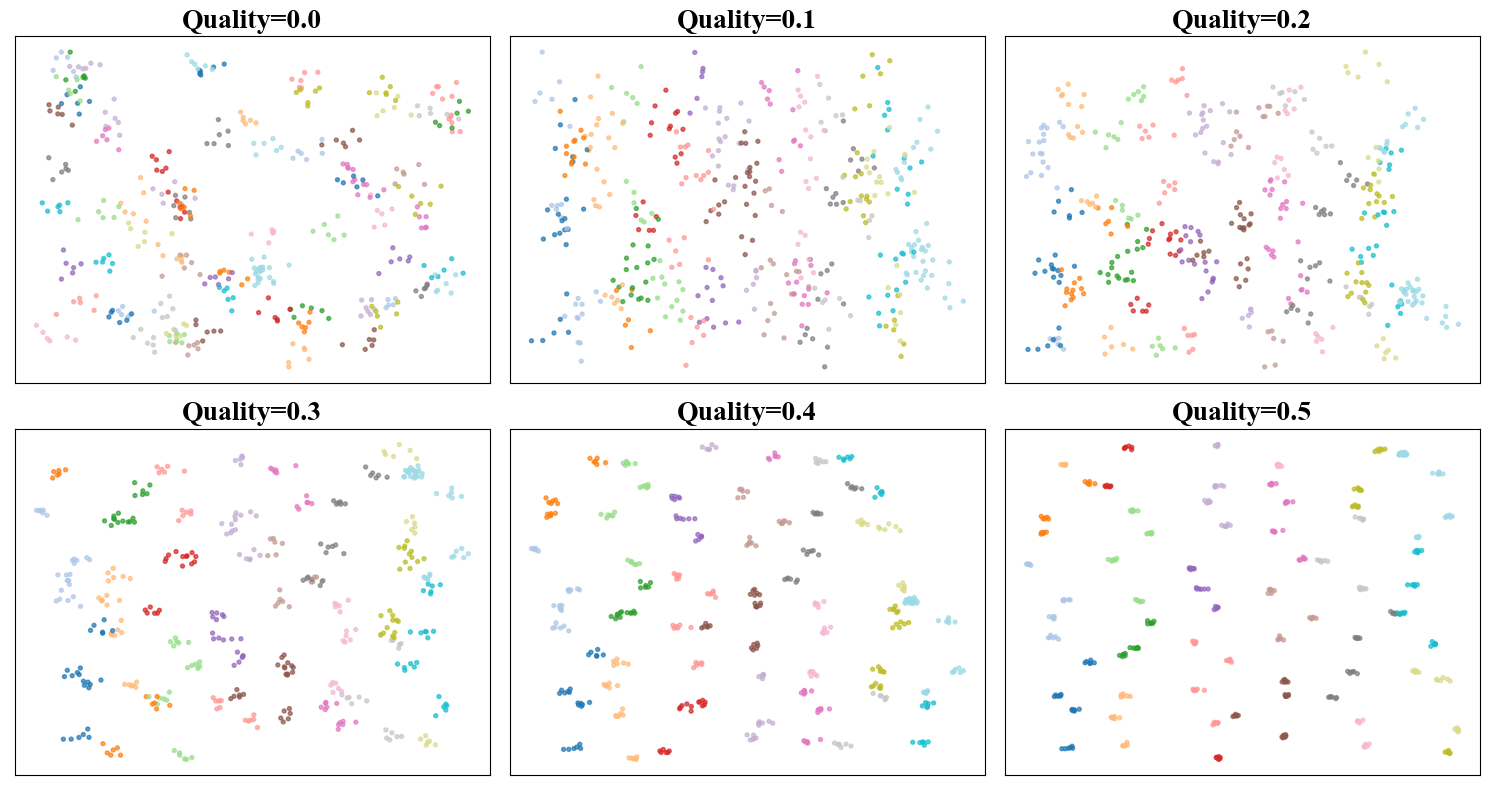

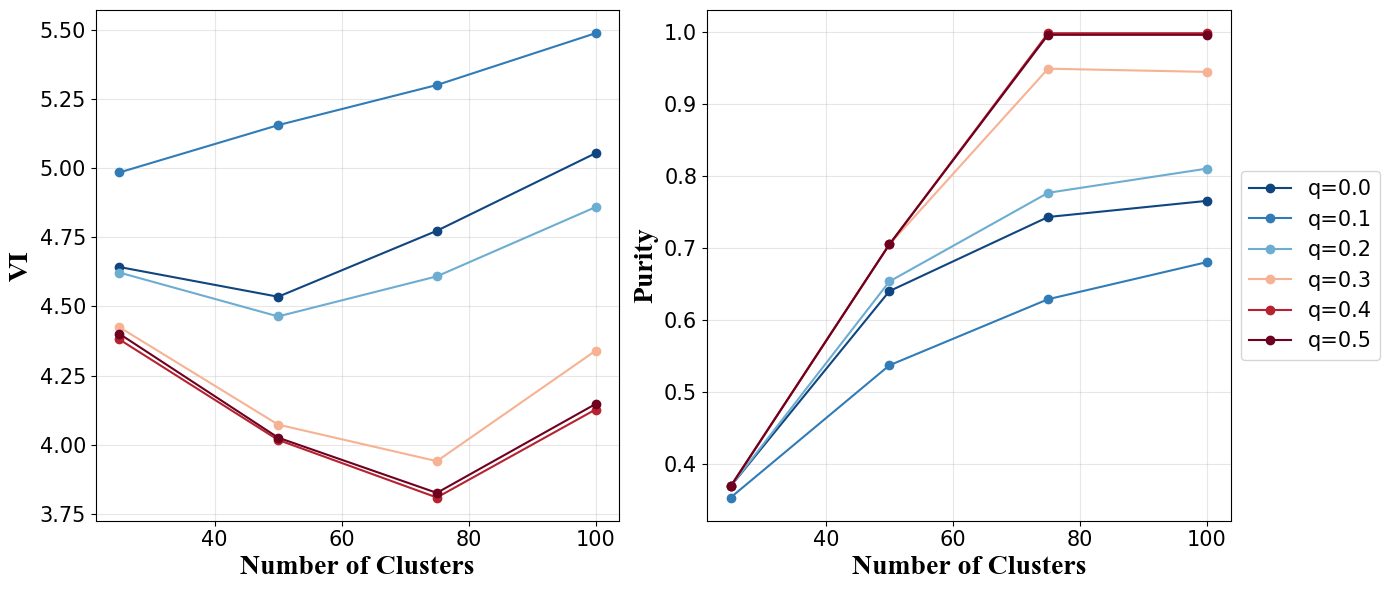

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import mutual_info_score
from sklearn.metrics.cluster import contingency_matrix


def variation_of_info(gold_clusters, pred_clusters):
    n = len(gold_clusters)
    contingency = contingency_matrix(gold_clusters, pred_clusters)
    contingency = contingency / n

    h_gold = -np.sum(contingency.sum(1) * np.log2(contingency.sum(1) + 1e-12))
    h_pred = -np.sum(contingency.sum(0) * np.log2(contingency.sum(0) + 1e-12))
    mi = mutual_info_score(gold_clusters, pred_clusters)

    return h_gold + h_pred - 2 * mi


def cluster_purity(gold_clusters, pred_clusters):
    contingency = contingency_matrix(gold_clusters, pred_clusters)
    return np.sum(np.amax(contingency, axis=0)) / np.sum(contingency)


np.random.seed(42)
n_samples = 447
n_true_clusters = 72

true_labels = np.repeat(np.arange(n_true_clusters), n_samples // n_true_clusters)
true_labels = np.concatenate([true_labels, [n_true_clusters - 1] * (n_samples - len(true_labels))])
np.random.shuffle(true_labels)


def generate_embeddings(labels, quality):
    np.random.seed(42)
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    embeddings = np.zeros((len(labels), 2))

    spacing = 5 + 20 * quality ** 1.5
    noise_std = 2.5 * (1 - quality) ** 2.5
    grid_size = int(np.sqrt(n_clusters) * (0.5 + 2 * quality))

    centers = {}
    for idx, cluster in enumerate(unique_labels):
        if quality < 0.1:
            centers[cluster] = np.random.uniform(-50, 50, 2)
        else:
            row = idx // grid_size
            col = idx % grid_size
            base = np.array([row * spacing, col * spacing])
            offset = np.random.normal(0, spacing * (1 - quality) / 2, 2)
            centers[cluster] = base + offset

    for i, cluster in enumerate(labels):
        noise = np.random.normal(0, noise_std, 2)
        embeddings[i] = centers[cluster] + noise

    return embeddings


qualities = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
embeddings = {q: generate_embeddings(true_labels, q) for q in qualities}

plt.figure(figsize=(15, 8))
for i, (q, emb) in enumerate(embeddings.items(), 1):
    plt.subplot(2, 3, i)
    plt.scatter(emb[:, 0], emb[:, 1], c=true_labels, s=8, alpha=0.7, cmap='tab20')
    plt.title(f"Quality={q}", fontsize=20, family='Times New Roman')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.savefig('images/purity_trend_embeddings.pdf', format='pdf')
plt.show()

# n_clusters_list = [20, 40, 60, 80, 100]
n_clusters_list = [25, 50, 75, 100]
metrics = {q: {'VI': [], 'Purity': []} for q in qualities}

for q in qualities:
    X = embeddings[q]
    for n_clusters in n_clusters_list:
        pred = KMeans(n_clusters, n_init=10, random_state=42).fit_predict(X)
        metrics[q]['VI'].append(variation_of_info(true_labels, pred))
        metrics[q]['Purity'].append(cluster_purity(true_labels, pred))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#104680', '#317CB7', '#6DADD1', '#F6B293', '#B72230', '#6D011F']
i=0
for q in qualities:
    ax1.plot(n_clusters_list, metrics[q]['VI'], marker='o', label=f'q={q}', color=colors[i])
    i+=1
ax1.set_xlabel("Number of Clusters", fontsize=20, family='Times New Roman')
ax1.set_ylabel("VI", fontsize=20, family='Times New Roman')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='y', labelsize=15)
ax1.tick_params(axis='x', labelsize=15)

i=0
for q in qualities:
    ax2.plot(n_clusters_list, metrics[q]['Purity'], marker='o', label=f'q={q}', color=colors[i])
    i += 1
ax2.set_xlabel("Number of Clusters", fontsize=20, family='Times New Roman')
ax2.set_ylabel("Purity", fontsize=20, family='Times New Roman')
ax2.tick_params(axis='y', labelsize=15)
ax2.tick_params(axis='x', labelsize=15)
ax2.grid(True, alpha=0.3)

plt.legend(bbox_to_anchor=(1, 0.5), loc='center left', fontsize=15)
plt.tight_layout()
plt.savefig('images/purity_trend_results.pdf', format='pdf')
plt.show()


In [ ]:
# 5.3 visualization

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


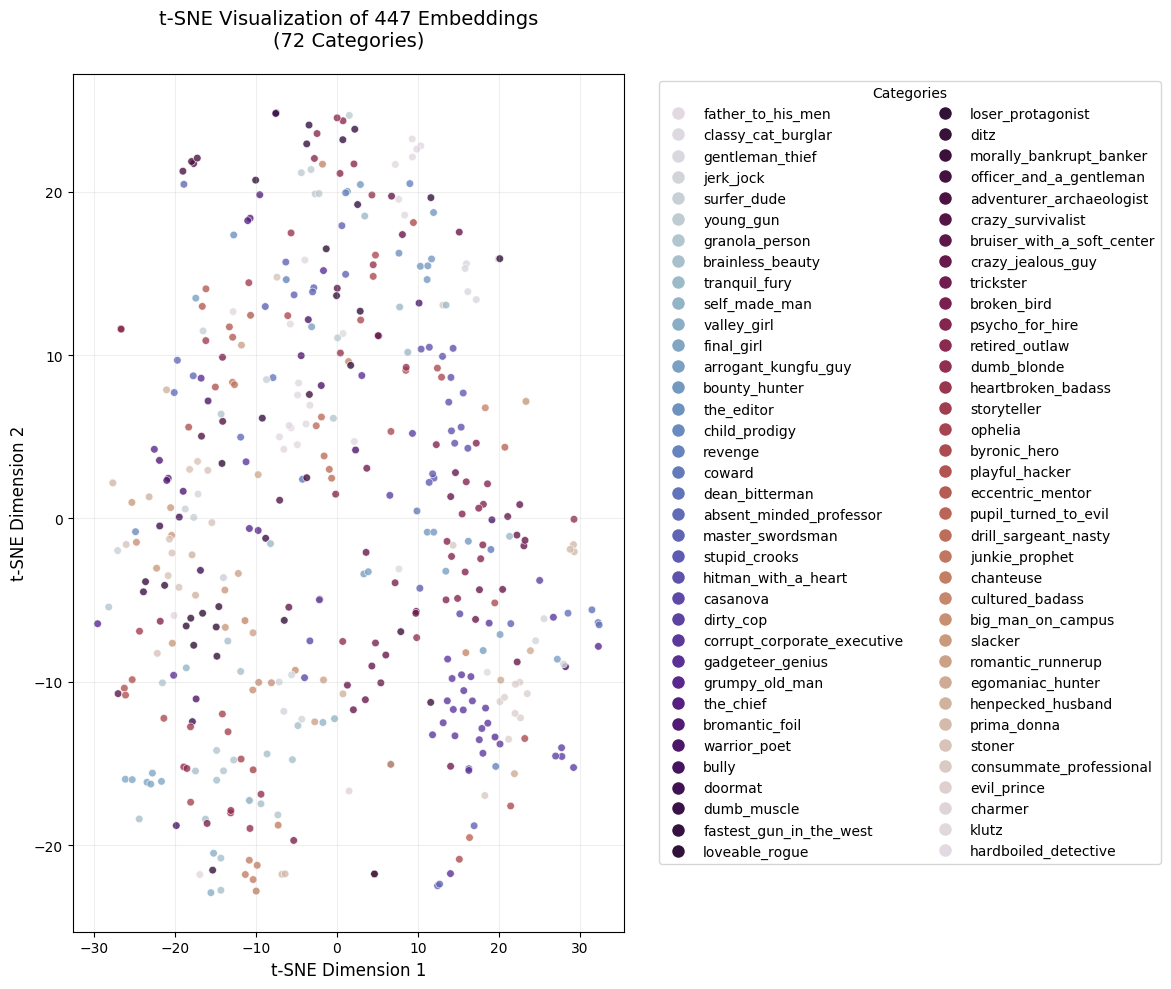

In [54]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap

categories = []
embeddings = []

with open('results/pt5_llama_-4layer_1words_20250528.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        categories.append(data['category'])
        embeddings.append(data['embedding'])

embeddings = np.array(embeddings)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)
embeddings_2d = tsne.fit_transform(embeddings)

unique_categories = list(set(categories))
category_to_id = {cat: i for i, cat in enumerate(unique_categories)}
color_ids = [category_to_id[cat] for cat in categories]

twilight = plt.get_cmap('twilight')
colors = twilight(np.linspace(0, 1, len(unique_categories)))
discrete_cmap = ListedColormap(colors)

plt.figure(figsize=(12, 10))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=color_ids,
    cmap=discrete_cmap,
    s=30,
    alpha=0.8,
    edgecolors='w',
    linewidths=0.5
)

legend_labels = [plt.Line2D([0], [0], 
                  marker='o', 
                  color='w', 
                  markerfacecolor=colors[i],
                  markersize=10,
                  label=cat) 
                for i, cat in enumerate(unique_categories)]

plt.legend(handles=legend_labels,
           title='Categories',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           ncol=1 if len(unique_categories) < 20 else 2)

plt.title(f't-SNE Visualization of {len(embeddings)} Embeddings\n({len(unique_categories)} Categories)',
          fontsize=14, pad=20)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('embedding_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

原始类别数量: 72
筛选后类别数量: 7
原始数据点数量: 447
筛选后数据点数量: 120


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


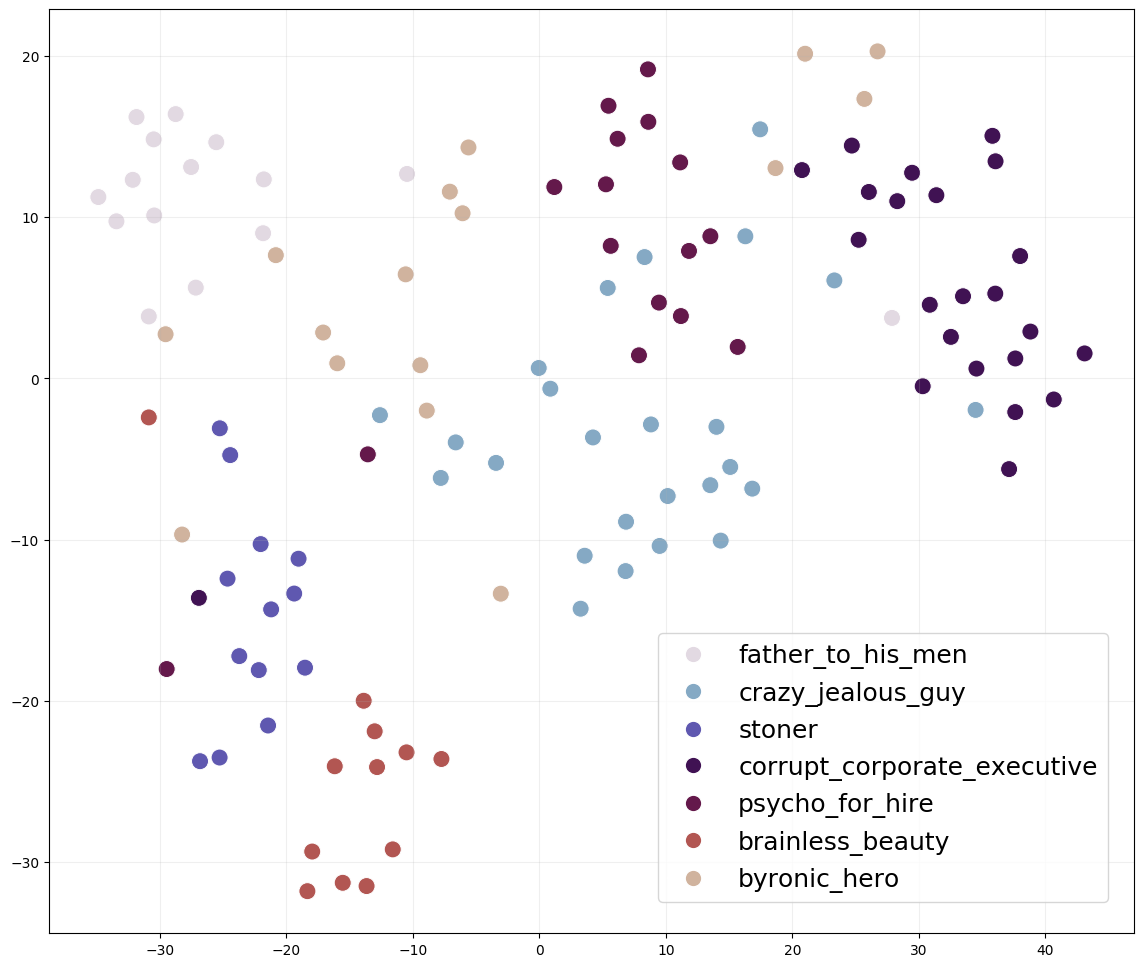

In [81]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap
from collections import defaultdict

category_counter = defaultdict(int)
raw_data = []

with open('results/pt5_llama_-4layer_1words_20250528.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        category = data['category']
        embedding = data['embedding']
        
        category_counter[category] += 1
        raw_data.append({
            'category': category,
            'embedding': embedding
        })

filtered_categories = []
filtered_embeddings = []
category_color_map = {}

for item in raw_data:
    if category_counter[item['category']] > 11:
        filtered_categories.append(item['category'])
        filtered_embeddings.append(item['embedding'])

embeddings = np.array(filtered_embeddings)
categories = np.array(filtered_categories)

unique_categories = list(set(categories))
category_to_id = {cat: i for i, cat in enumerate(unique_categories)}
color_ids = [category_to_id[cat] for cat in categories]

tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(embeddings)//10)),
    learning_rate=200,
    n_iter=1000,
    random_state=42
)
embeddings_2d = tsne.fit_transform(embeddings)

twilight = plt.get_cmap('twilight')
colors = twilight(np.linspace(0, 0.9, len(unique_categories)))
discrete_cmap = ListedColormap(colors)

plt.figure(figsize=(14, 12))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=color_ids,
    cmap=discrete_cmap,
    s=150,
    alpha=1,
    edgecolors='w',
    linewidths=0.7
)

legend_labels = [plt.Line2D([0], [0], 
                  marker='o', 
                  color='w', 
                  markerfacecolor=colors[i],
                  markersize=12,
                  label=f"{cat}") 
                for i, cat in enumerate(unique_categories)]

ncol = 1
if len(unique_categories) > 30:
    ncol = 3
elif len(unique_categories) > 15:
    ncol = 2

plt.legend(handles=legend_labels,
           bbox_to_anchor=(0.55, 0.02),
           loc='lower left',
           ncol=ncol,
           fontsize=18)

plt.grid(alpha=0.2)

plt.savefig('images/embedding-visualization.pdf', format='pdf')
plt.show()